In [118]:
import pandas as pd
import geopandas as gpd
import rioxarray
from shapely.geometry import box, Point
import cv2
import matplotlib.pyplot as plt
from georefcam.camera_model import CTCameraModel
from georefcam.dem import RasterioDEM
from georefcam.georefcam import GeoRefCam
import numpy as np
import pyvista as pv
import rioxarray
from PIL import Image
import glob
import os
from dem_utils import compute_dem_bbox_from_point, download_dem_eio, reproject_and_save_dem

In [119]:
sites_data = pd.read_csv("data/sites.csv")
sites_data

,name,lat,lon,elevation,fov_x,fov_y
0,brison,44.545155,4.216534,830,87,44
1,marguerite,44.688492,4.313501,984,87,44
2,cabanelle,43.786647,7.419608,1080,87,44
3,courmettes,43.715592,7.026486,800,87,44
4,valbonne,43.623364,7.027940,200,87,44
5,croix-augas,48.426746,2.710876,150,54,44


In [120]:
images = glob.glob("data/images/*")
images.sort()
img_file = images[5]
site, azimuth = os.path.basename(img_file).split('_')[1].split('-')
site, azimuth

('brison', '200')

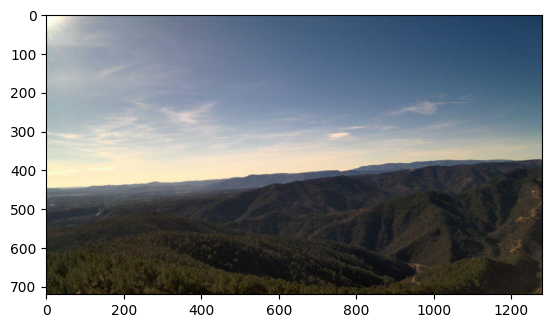

In [121]:
im = cv2.imread(img_file)
plt.imshow(im[:,:,::-1])

In [122]:
site_data = sites_data[sites_data["name"]==site]
site_data

,name,lat,lon,elevation,fov_x,fov_y
0,brison,44.545155,4.216534,830,87,44


In [123]:
lat = float(site_data["lat"])
lon = float(site_data["lon"])
pitch, roll = 0, 0
elevation = int(site_data["elevation"])  # Elevation + tour size 
fov_x = int(site_data["fov_x"])
fov_y = int(site_data["fov_y"])
lat, lon, elevation

(44.5451545715, 4.2165341377, 830)

In [124]:
azimuth = 217
pitch = -3

In [125]:
bbox = compute_dem_bbox_from_point(lat, lon)
download_dem_eio(bbox)
reproject_and_save_dem("srtm_dem.tif", "srtm_dem_l93.tif")


Running: eio --product SRTM1 clip --bounds 3.7673764956402387 44.22416079256764 4.665691779759761 44.86438805459089 --output srtm_dem.tif
✅ DEM downloaded: srtm_dem.tif
✅ Reprojected DEM saved to srtm_dem_l93.tif


In [126]:
# === Load Camera Metadata ===
cam_name = f"{site}-{azimuth}"
cam_info = pd.Series({
    "login": cam_name,
    "lat": lat,
    "lon": lon,
    "geometry": Point(lon, lat),
    "azimuth" : float(azimuth),
    "pitch" : pitch,
    "elevation" : elevation,
    "roll" : roll
})

# Create a GeoSeries with correct CRS
gdf_cams = gpd.GeoDataFrame([cam_info], geometry="geometry", crs="EPSG:4326")


# === Load Test Image ===
test_img = Image.open(img_file)
test_img_res = test_img.size



In [127]:
# === Prepare DEM ===
dem_data = rioxarray.open_rasterio("srtm_dem_l93.tif", masked=True).squeeze()
if dem_data.rio.crs != "EPSG:2154":
    dem_data = dem_data.rio.reproject("EPSG:2154")
dem_path = "dem_l93.tif"
dem_data.rio.to_raster(dem_path)

dem = RasterioDEM(dem_path, crs="EPSG:2154")
dem.build_pcd(sample_step=10)
dem.build_mesh()


In [128]:
# === Create Camera Model ===
cam_model = CTCameraModel(
    test_img_res,
    fov_x, fov_y,  # FoV x, y
    cam_info.azimuth,
    cam_info.pitch,
    cam_info.roll,  # roll
    cam_info.lat,
    cam_info.lon,
    cam_info.elevation,
)
# Manual overrides


geocam = GeoRefCam(cam_model, dem)


In [129]:
# === PyVista DEM Projection View ===
def get_direction_vector(azimuth, pitch, length=1):
    return np.array([
        length * np.sin(np.radians(azimuth)),
        length * np.cos(np.radians(azimuth)),
        -length * np.sin(np.radians(pitch))
    ])

cam_dirvec = get_direction_vector(geocam.camera_model.yaw_deg, geocam.camera_model.pitch_deg)

# Reproject camera location if needed
if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(
        np.array([geocam.camera_model.cam_loc[:3]])
    )[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]


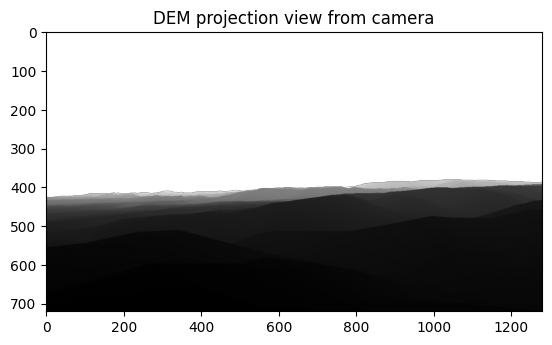

In [130]:
# Setup PyVista camera
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = geocam.camera_model.view_y_deg
pv_camera.clipping_range = (30, 1e5)
pv_camera.up = (0, 0, 1)

# Create plot
plotter = pv.Plotter(off_screen=True, window_size=test_img.size)
plotter.camera = pv_camera

plot_pv_meshgrid = pv.StructuredGrid(*[geocam.dem.pcd[:, :, i] for i in range(3)])
plot_pv_meshgrid["alt"] = geocam.dem.pcd[:, :, 2].ravel(order="F")
plotter.add_mesh(plot_pv_meshgrid, lighting=False)
plotter.remove_scalar_bar()

plotter.screenshot()
dem_depth = -1 * plotter.get_image_depth()



# === Display Result ===
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")

plt.show()


In [131]:
# --- NaN-safe normalization for any input ---
def safe_normalize(arr, th_min=0, th_max=100, scale=255.0):
    mask = ~np.isnan(arr)
    if not np.any(mask):
        return np.zeros_like(arr, dtype="float32")

    min_val = np.nanpercentile(arr, th_min)
    max_val = np.nanpercentile(arr, th_max)
    if max_val - min_val == 0:
        return np.zeros_like(arr, dtype="float32")

    norm = (arr - min_val) / (max_val - min_val)
    norm = np.clip(norm, 0, 1)

    result = np.zeros_like(arr, dtype="float32")
    result[mask] = norm[mask] * scale
    return result




In [132]:

normalized = safe_normalize(dem_depth.copy(), th_min=1, th_max=90, scale=255.0).astype(np.uint8)
cv2.imwrite("dem.jpg", 255-normalized)

True

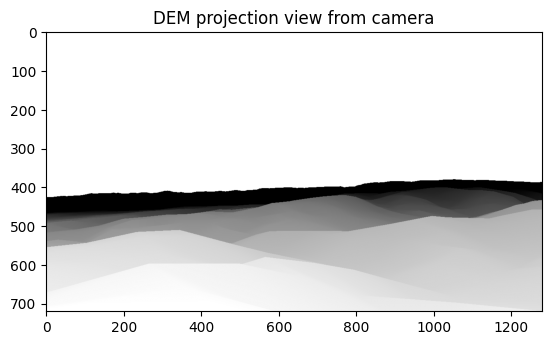

In [133]:
plt.imshow(255-normalized, cmap='gray')
plt.title("DEM projection view from camera")
plt.show()

Device set to use mps:0


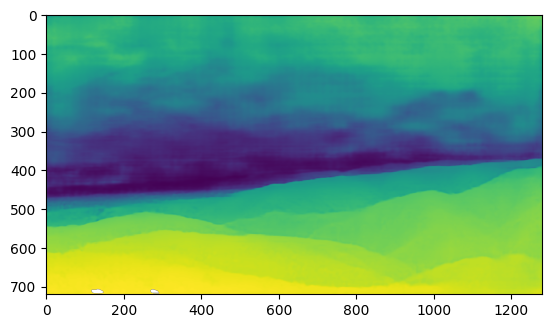

In [135]:
from transformers import pipeline
from PIL import Image
import requests

# load pipe
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf")

refcam_img = Image.open(img_file)
depth_pred = pipe(refcam_img)["depth"]

img_depth = np.asarray(depth_pred)

# Invert to make depth increase with distance
mid = (np.nanmin(img_depth) + np.nanmax(img_depth)) / 2
img_depth = 2 * mid - img_depth
img_depth = np.where(img_depth == 255, np.nan, img_depth)
plt.imshow(img_depth)